# 5 代表点

> **图 5.1**：7个随机采样点（左）与最优采样点（右）的经验分布函数。

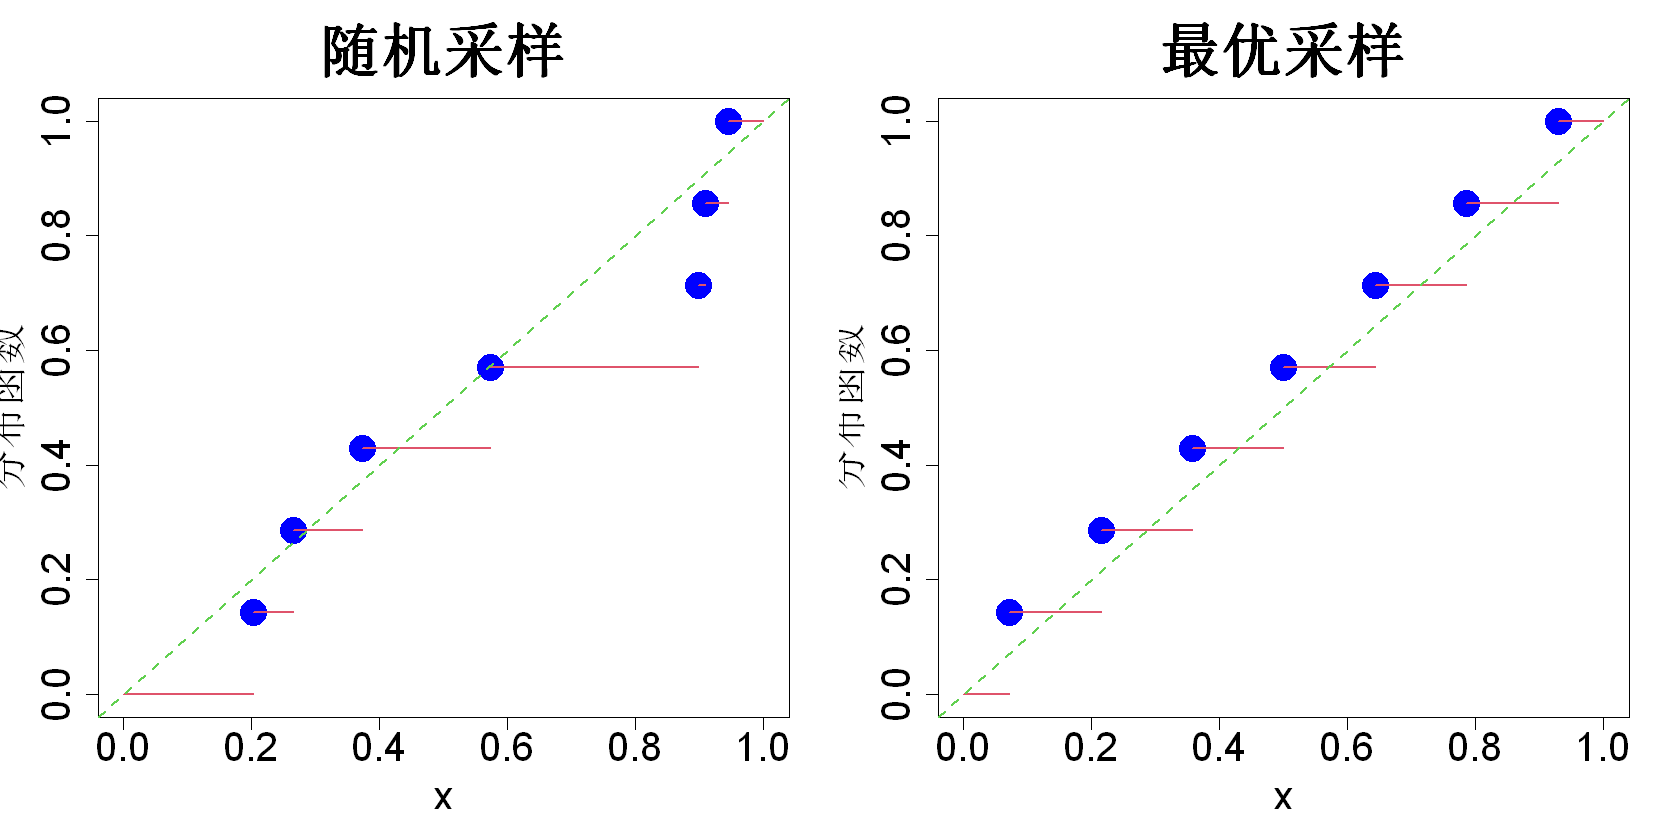

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.1-plot.RData")){
  set.seed(1)
  n=7
  x1=sort(runif(n)) # 7x1
  d1=cbind(x1,(1:n)/n) # 7x2
  x2=((1:n)-.5)/n # 7x1
  d2=cbind(x2,(1:n)/n) # 7x2
  save(d1,d2,x1,x2,n,file="data/5.1-plot.RData")
}

load("data/5.1-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
plot(d1,xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,xlab="x",ylab="分布函数",main="随机采样",cex.lab=2,cex.main=3,cex.axis=2)
segments(0,0,x1[1],0,col=2,lwd=2)
for(i in 1:(n-1)) segments(x1[i],i/n,x1[i+1],i/n,col=2,lwd=2)
segments(x1[n],1,1,1,col=2,lwd=2)
abline(0,1,col=3,lwd=2,lty=2)
plot(d2,xlim=c(0,1),ylim=c(0,1),pch=16,col="blue",cex=3,xlab="x",ylab="分布函数",main="最优采样",cex.lab=2,cex.main=3,cex.axis=2)
segments(0,0,x2[1],0,col=2,lwd=2)
for(i in 1:(n-1)) segments(x2[i],i/n,x2[i+1],i/n,col=2,lwd=2)
segments(x2[n],1,1,1,col=2,lwd=2)
abline(0,1,col=3,lwd=2,lty=2)

> **图 5.2**：在二维单位正方形 $[0, 1]^2$ 内，包含 20 个采样点的蒙特卡洛样本（左）、索博尔序列（中）以及均匀设计（右）。

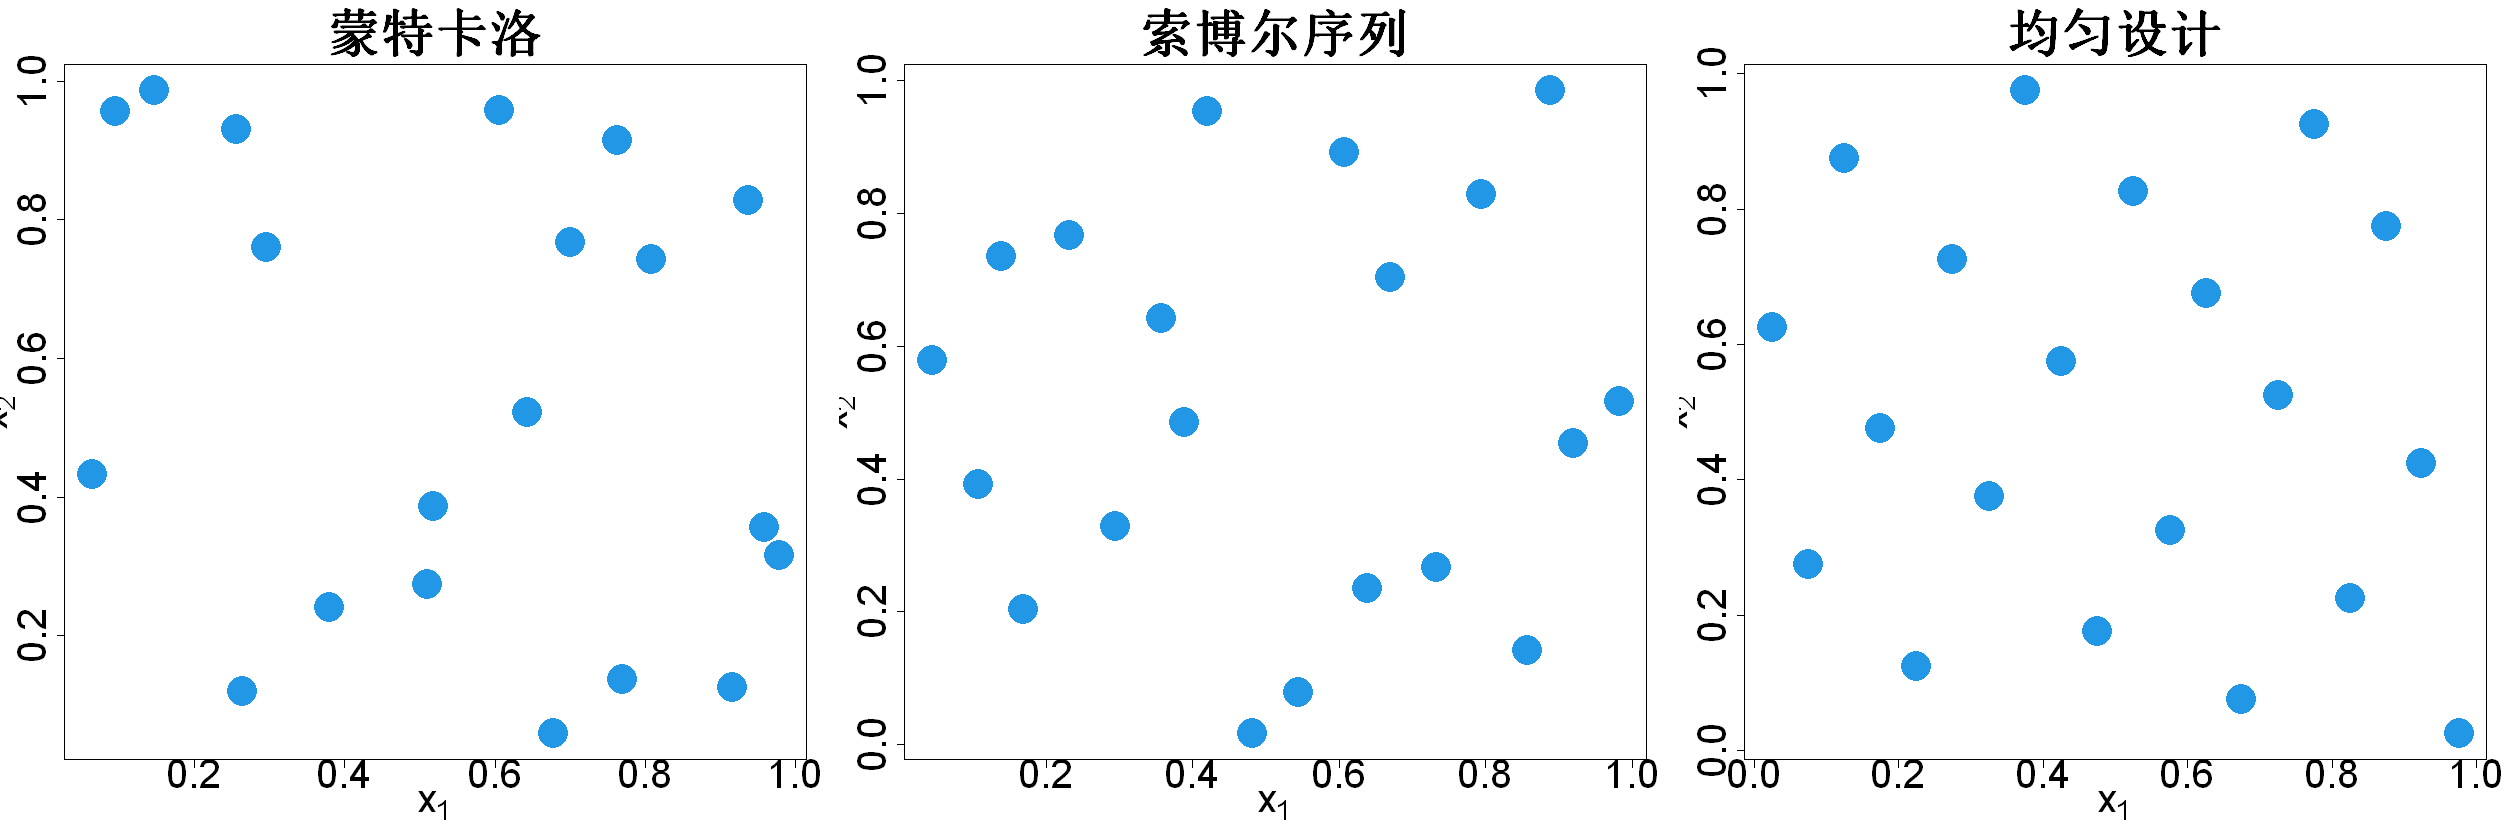

In [2]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.2-plot.RData")){
  p=2; n=20
  set.seed(6)
  library(spacefillr)
  library(SFDesign)
  R=matrix(runif(n*2),ncol=2) # 20x2
  S=generate_sobol_set(n,p,seed=sample(1:10000,1)) # 20x2
  D=uniform.optim(uniformLHD(n,p)$design)$design # 20x2
  save(R,S,D,file="data/5.2-plot.RData")
}

load("data/5.2-plot.RData")

options(repr.plot.width=21,repr.plot.height=7)
par(mfrow=c(1,3))
plot(R,pch=16,col=4,cex=5,cex.axis=3,main="蒙特卡洛",cex.main=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=3)
plot(S,pch=16,col=4,cex=5,cex.axis=3,main="索博尔序列",cex.main=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=3)
plot(D,pch=16,col=4,cex=5,cex.axis=3,main="均匀设计",cex.main=4,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=3)

> **图5.3**：三种采样方法（蒙特卡洛、索博尔序列、均匀设计）对应的环绕偏差（左）与二维积分计算结果（右）。

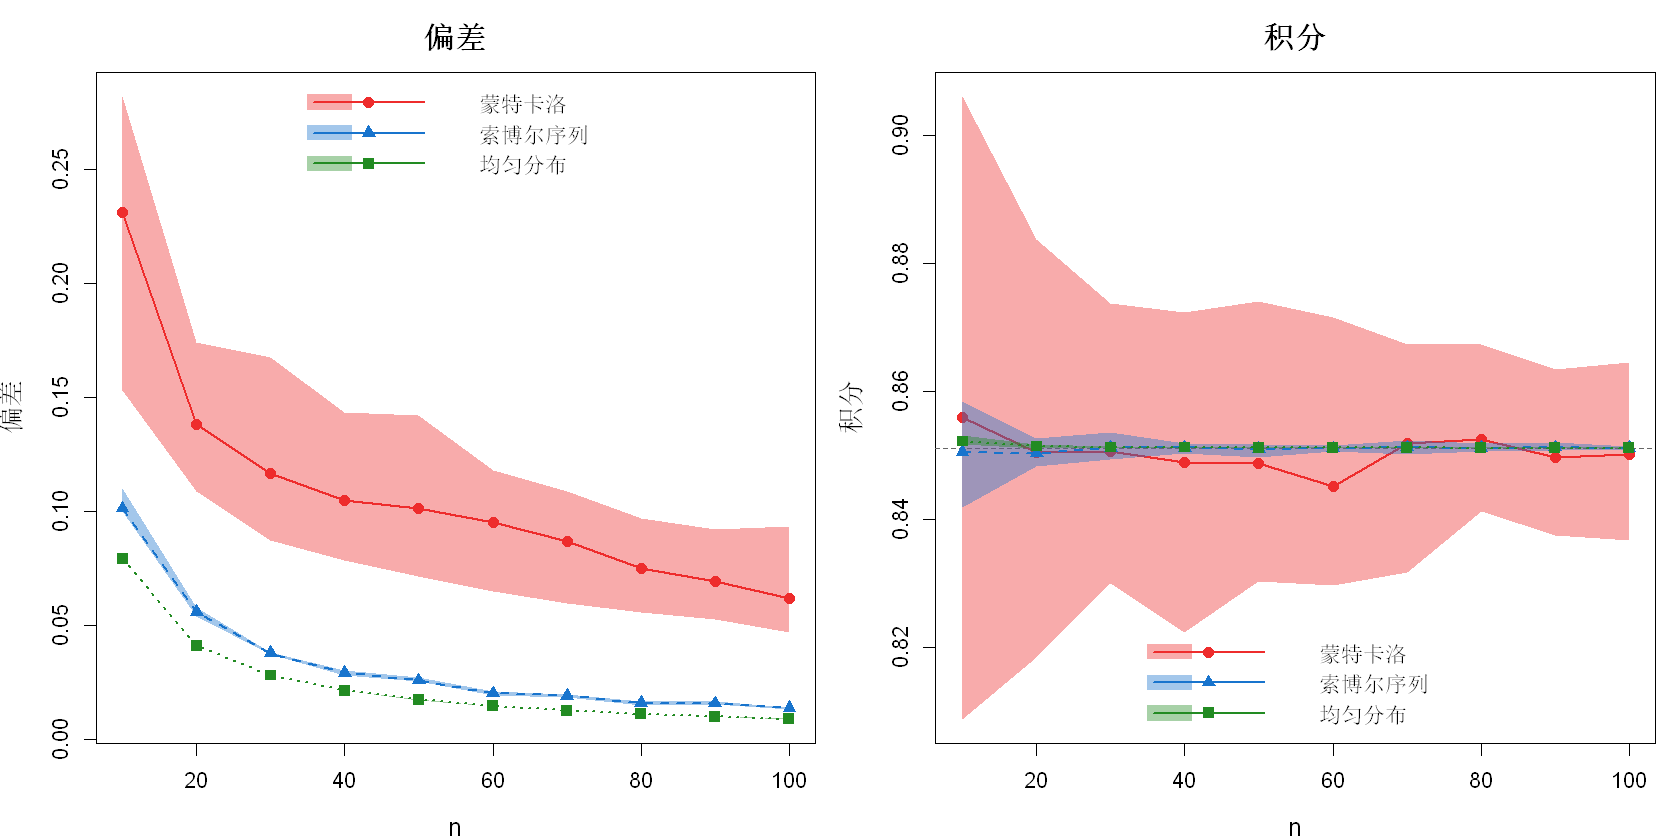

In [3]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.3-plot.RData")){
  set.seed(1)
  p=2
  h=function(x) exp(-sum((x-.5)^2))
  n=seq(10,100,by=10)
  randw=sobw=uniw=matrix(0,nrow=10,ncol=30) # 10x30
  rand=sob=uni=matrix(0,nrow=10,ncol=30) # 10x30
  library(spacefillr)
  library(SFDesign)
  # 该双层循环运算速度极慢（约需 60 分钟），结果缓存于 data/5.3-matrix.RData，请谨慎重跑
  if(!file.exists("data/5.3-matrix.RData")){
    for(j in 1:10){
      for(i in 1:30){
        R=matrix(runif(n[j]*2),ncol=2)
        S=generate_sobol_set(n[j],2,seed=sample(1:10000,1))
        D=uniform.optim(uniformLHD(n[j],p)$design)$design
        randw[j,i]=uniform.crit(R)
        sobw[j,i]=uniform.crit(S)
        uniw[j,i]=uniform.crit(D)
        rand[j,i]=mean(apply(R,1,h))
        sob[j,i]=mean(apply(S,1,h))
        uni[j,i]=mean(apply(D,1,h))
      }
    }
    save(randw,sobw,uniw,rand,sob,uni,file="data/5.3-matrix.RData")
  } else load("data/5.3-matrix.RData")
  design=expand.grid(n=n,method=c("MC","Sobol","Uniform"))
  wd=cbind(design,rbind(randw,sobw,uniw)) # 30x32
  colnames(wd)=c("n","method",paste0("V",1:30))
  integration=cbind(design,rbind(rand,sob,uni)) # 30x32
  colnames(integration)=c("n","method",paste0("V",1:30))
  true=pi*(pnorm(.5*sqrt(2))-pnorm(-.5*sqrt(2)))^2 # 1x1
  save(wd,integration,true,file="data/5.3-plot.RData")
}

load("data/5.3-plot.RData")
get.quant=function(dat){
  vals=as.matrix(dat[,paste0("V",1:30)])
  l=apply(vals,1,quantile,probs=.05)
  m=apply(vals,1,quantile,probs=.5)
  u=apply(vals,1,quantile,probs=.95)
  cbind(l,m,u)
}
methods=unique(wd$method)
n=wd$n[wd$method==methods[1]]
cols=c("firebrick2","dodgerblue3","forestgreen")
pchs=c(16,17,15); ltys=1:3

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2),mar=c(4,4,3,1),cex.lab=1.3,cex.axis=1.1,cex.main=1.5)
q.wd=get.quant(wd)
plot(0,type="n",xlim=range(n),ylim=range(q.wd),xlab="n",ylab="偏差",main="偏差")
for(k in 1:3){
  idx=wd$method==methods[k]
  polygon(c(n,rev(n)),c(q.wd[idx,"l"],rev(q.wd[idx,"u"])),
          col=adjustcolor(cols[k],alpha.f=.4),border=NA)
  lines(n,q.wd[idx,"m"],col=cols[k],lwd=2,lty=ltys[k])
  points(n,q.wd[idx,"m"],col=cols[k],pch=pchs[k],cex=1.2)
}
legend("topright",legend=c("蒙特卡洛","索博尔序列","均匀分布"),col=cols,pch=pchs,lwd=2,fill=adjustcolor(cols,alpha.f=.4),border=NA,bty="n",cex=1.2)
q.int=get.quant(integration)
plot(0,type="n",xlim=range(n),ylim=range(q.int),xlab="n",ylab="积分",main="积分")
abline(h=true,lty=2,col="gray40")
for(k in 1:3){
  idx=integration$method==methods[k]
  polygon(c(n,rev(n)),c(q.int[idx,"l"],rev(q.int[idx,"u"])),
          col=adjustcolor(cols[k],alpha.f=.4),border=NA)
  lines(n,q.int[idx,"m"],col=cols[k],lwd=2,lty=ltys[k])
  points(n,q.int[idx,"m"],col=cols[k],pch=pchs[k],cex=1.2)
}
legend("bottomright",legend=c("蒙特卡洛","索博尔序列","均匀分布"),col=cols,pch=pchs,lwd=2,fill=adjustcolor(cols,alpha.f=.4),border=NA,bty="n",cex=1.2)

> **图 5.4**：通过均匀设计的逆概率变换得到的二元正态分布（左）与伽马分布（右）的 50 个代表点。图中同时展示了两种分布的图像与等高线。

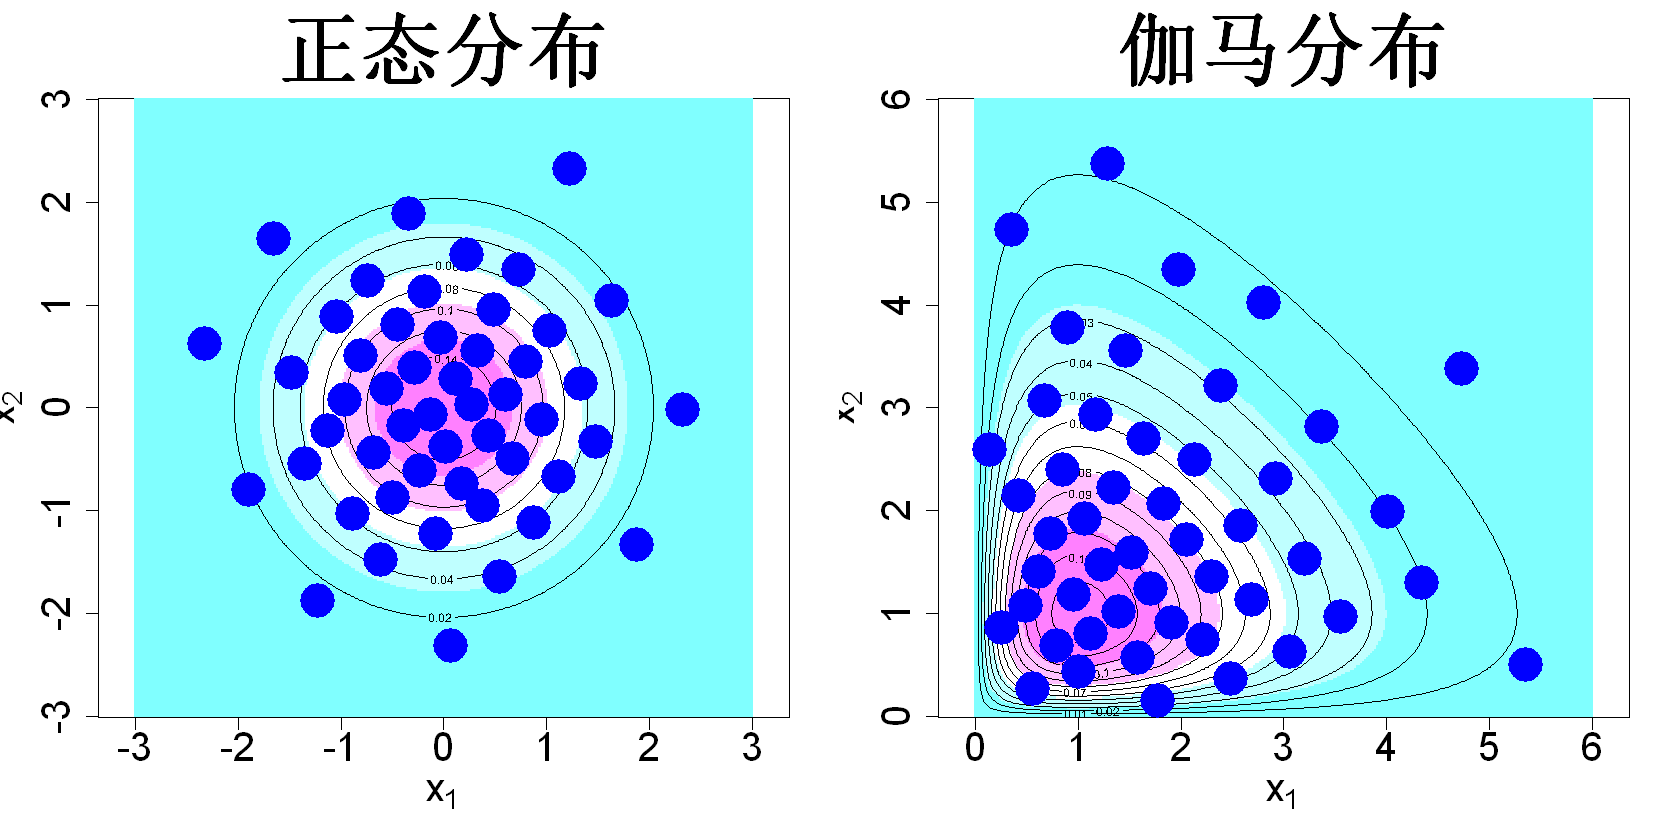

In [4]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.4-plot.RData")){
  p=2; n=50; N.plot=300
  set.seed(6)
  library(SFDesign)
  d=uniform.optim(uniformLHD(n,p)$design)$design # 50x2
  D1=qnorm(d) # 50x2
  f1=function(x) exp(-.5*sum(x^2))/(2*pi)
  p11=seq(-3,3,length.out=N.plot) # 300x1
  p12=seq(-3,3,length.out=N.plot) # 300x1
  fc1=matrix(apply(expand.grid(p11,p12),1,f1),N.plot,N.plot) # 300x300
  D2=qgamma(d,2,1) # 50x2
  f2=function(x) prod(dgamma(x,2,1))
  p21=seq(0,6,length.out=N.plot) # 300x1
  p22=seq(0,6,length.out=N.plot) # 300x1
  fc2=matrix(apply(expand.grid(p21,p22),1,f2),N.plot,N.plot) # 300x300
  save(D1,D2,p11,p12,p21,p22,fc1,fc2,file="data/5.4-plot.RData")
}

load("data/5.4-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
image(p11,p12,fc1,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="正态分布",cex.main=4,asp=1)
contour(p11,p12,fc1,add=TRUE,nlevels=10)
points(D1,pch=16,col="blue",cex=4)
image(p21,p22,fc2,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="伽马分布",cex.main=4,asp=1)
contour(p21,p22,fc2,add=TRUE,nlevels=10)
points(D2,pch=16,col="blue",cex=4)

> **图 5.5**：通过对均匀设计进行罗森布拉特变换得到的相关二元正态分布代表点，叠加绘制于该分布的图像之上。

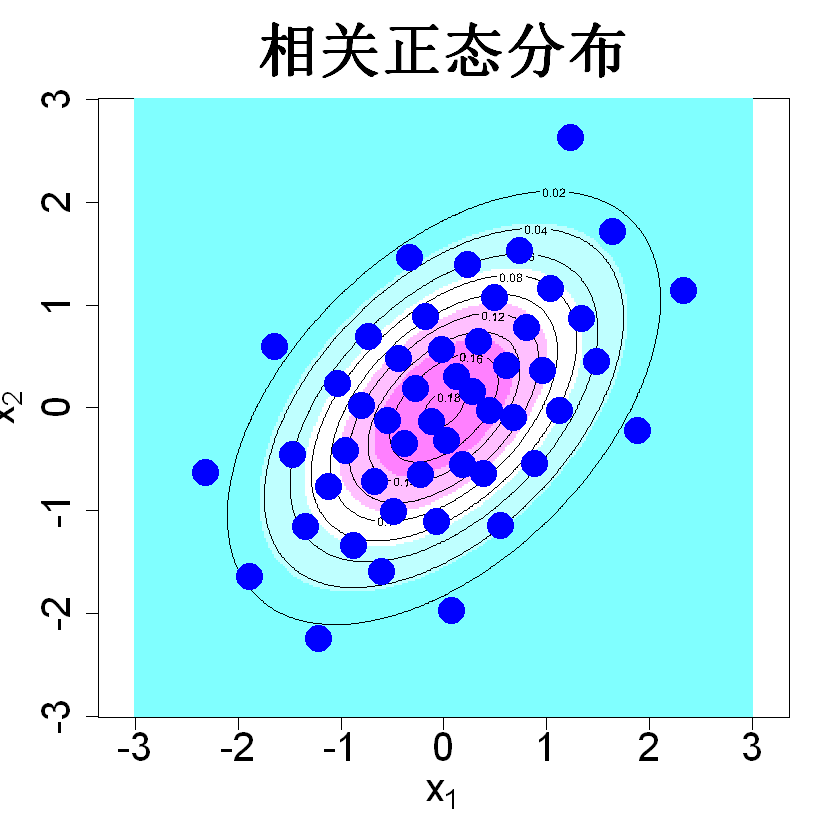

In [5]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.5-plot.RData")){
  p=2; n=50; N.plot=300
  set.seed(6)
  library(SFDesign)
  d=uniform.optim(uniformLHD(n,p)$design)$design # 50x2
  library(mnormt)
  x1=qnorm(d[,1]) # 50x1
  x2=qnorm(d[,2],mean=.5*x1,sd=sqrt(1-.5^2)) # 50x1
  D=cbind(x1,x2) # 50x2
  colnames(D)=c("x1","x2")
  f=function(x) dmnorm(x,mean=c(0,0),varcov=matrix(c(1,.5,.5,1),2,2))
  p1=seq(-3,3,length.out=N.plot) # 300x1
  p2=seq(-3,3,length.out=N.plot) # 300x1
  fc=matrix(apply(expand.grid(p1,p2),1,f),N.plot,N.plot) # 300x300
  save(D,p1,p2,fc,file="data/5.5-plot.RData")
}

load("data/5.5-plot.RData")

options(repr.plot.width=7,repr.plot.height=7)
image(p1,p2,fc,cex.axis=2,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,col=cm.colors(5),main="相关正态分布",cex.main=3,asp=1)
contour(p1,p2,fc,add=TRUE,nlevels=10)
points(D,pch=16,col="blue",cex=3)

> **图 5.6**：双变量正态分布（左）与伽马分布（右）的 50 个支撑点。图中同时展示了两类分布的图像与等高线。

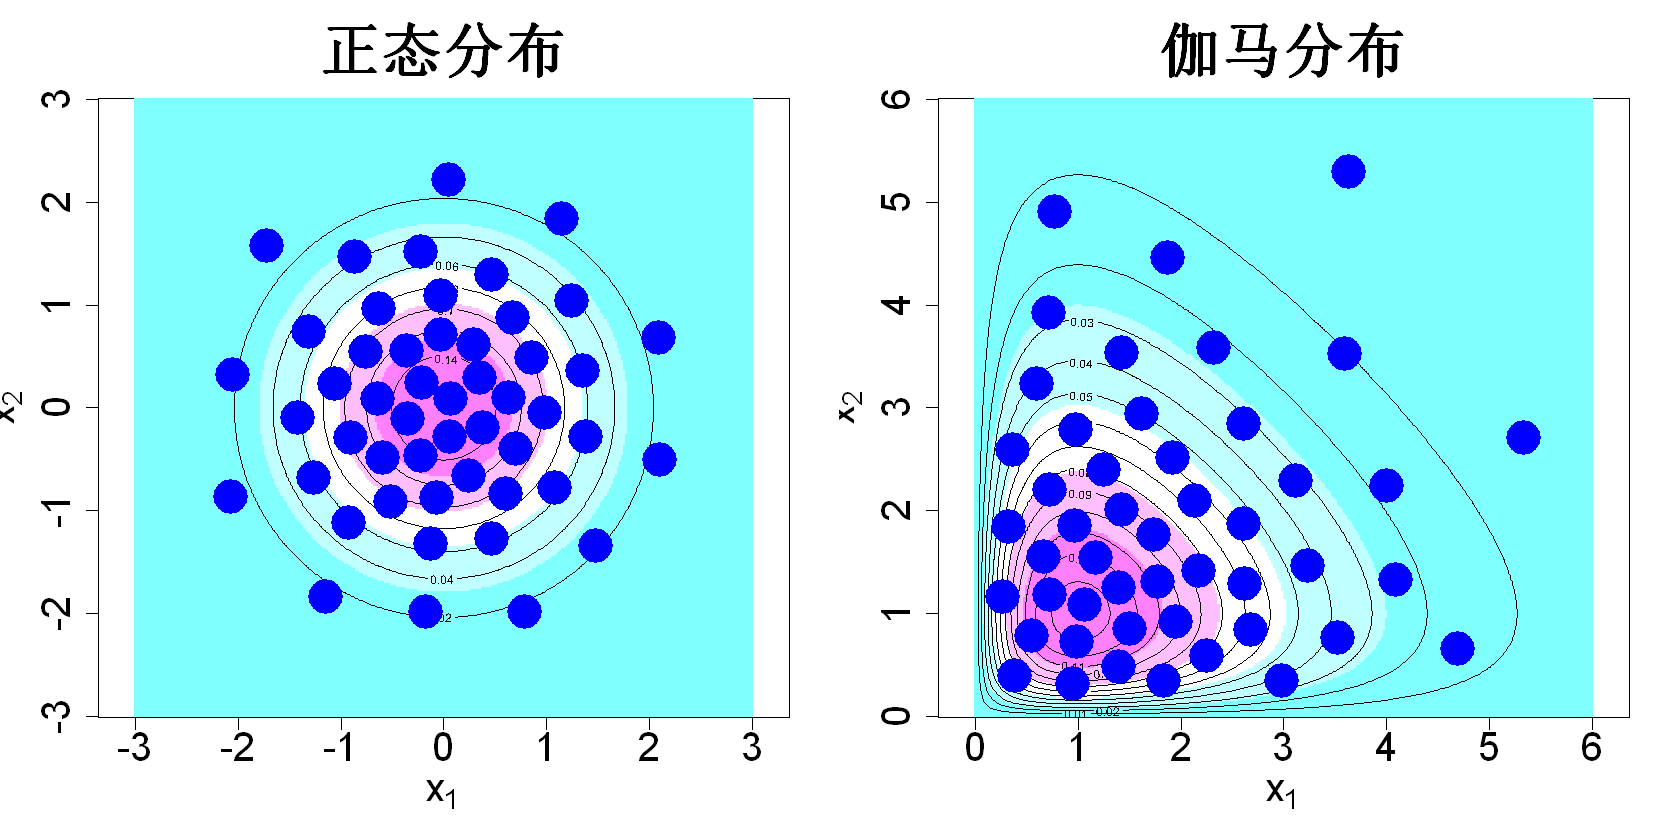

In [6]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.6-plot.RData")){
  p=2; n=50; N.plot=300
  set.seed(1)
  library(support)
  D1=sp(n,p,dist.str=rep("normal",p))$sp # 50x2
  f1=function(x) exp(-.5*sum(x^2))/(2*pi)
  p11=seq(-3,3,length.out=N.plot) # 300x1
  p12=seq(-3,3,length.out=N.plot) # 300x1
  fc1=matrix(apply(expand.grid(p11,p12),1,f1),N.plot,N.plot) # 300x300
  dist.param=vector("list",p)
  for(l in 1:p) dist.param[[l]]=c(2,1)
  D2=sp(n,p,dist.str=rep("gamma",p),dist.param=dist.param)$sp # 50x2
  f2=function(x) prod(dgamma(x,2,1))
  p21=seq(0,6,length.out=N.plot) # 300x1
  p22=seq(0,6,length.out=N.plot) # 300x1
  fc2=matrix(apply(expand.grid(p21,p22),1,f2),N.plot,N.plot) # 300x300
  save(D1,D2,p11,p12,p21,p22,fc1,fc2,file="data/5.6-plot.RData")
}

load("data/5.6-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
image(p11,p12,fc1,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(5),main="正态分布",cex.main=3,cex.lab=2,cex.axis=2,asp=1)
contour(p11,p12,fc1,add=TRUE,nlevels=10)
points(D1,pch=16,col="blue",cex=4)
image(p21,p22,fc2,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(5),main="伽马分布",cex.main=3,cex.lab=2,cex.axis=2,asp=1)
contour(p21,p22,fc2,add=TRUE,nlevels=10)
points(D2,pch=16,col="blue",cex=4)

> **图 5.7**：式 (5.8) 中相关二元正态分布的 50 个支撑点（左图）以及式 (4.49) 中香蕉形密度（右图）。同时展示了各分布的图像与等高线。

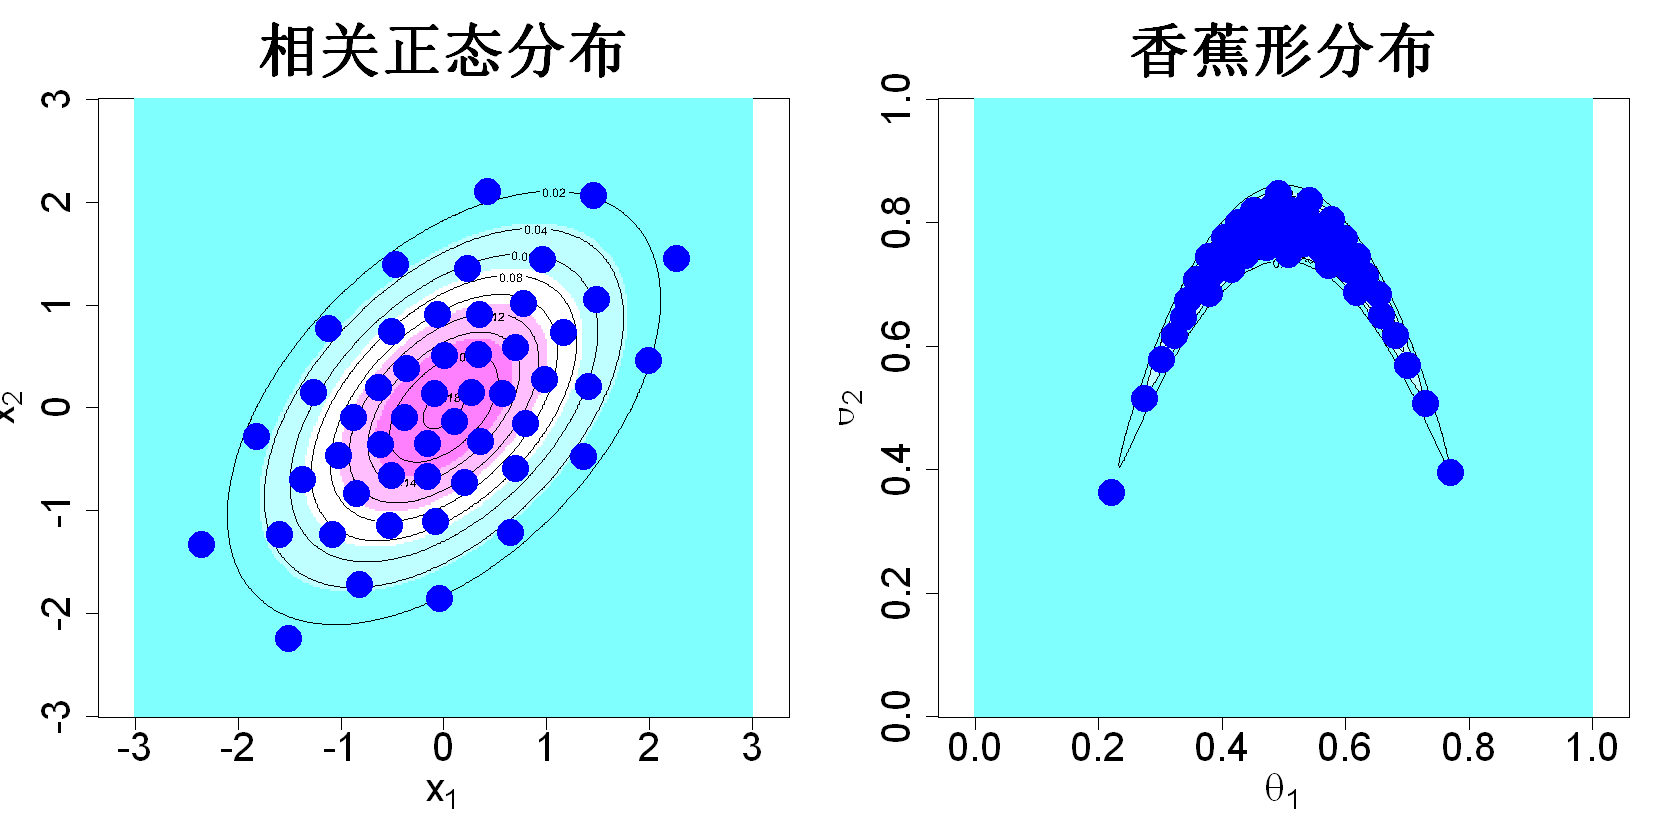

In [7]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.7-plot.RData")){
  p=2; n=50; N=10000; N.plot=300
  set.seed(1)
  library(mnormt)
  X1=rmnorm(N,mean=c(0,0),varcov=matrix(c(1,.5,.5,1),2,2))
  library(support)
  D1=sp(n,p,dist.samp=X1)$sp # 50x2
  f1=function(x) dmnorm(x,mean=c(0,0),varcov=matrix(c(1,.5,.5,1),2,2))
  p11=seq(-3,3,length.out=N.plot) # 300x1
  p12=seq(-3,3,length.out=N.plot) # 300x1
  fc1=matrix(apply(expand.grid(p11,p12),1,f1),N.plot,N.plot) # 300x300
  logf=function(para){
    l1=-40; u1=40; l2=-25; u2=10
    x1=l1+(u1-l1)*para[1]
    x2=l2+(u2-l2)*para[2]
    -.5*(x1^2/100+(x2+.03*x1^2-3)^2)
  }
  p21=seq(0,1,length.out=N.plot) # 300x1
  p22=seq(0,1,length.out=N.plot) # 300x1
  fc2=matrix(exp(apply(expand.grid(p21,p22),1,logf)),N.plot,N.plot) # 300x300
  library(adaptMCMC)
  a=MCMC(logf,n=100000,init=c(.5,.8),acc.rate=0.4) # MCMC 采样 100000 次，较耗时
  X2=a$samples
  D2=sp(n,p,dist.samp=X2)$sp # 50x2
  save(D1,D2,p11,p12,p21,p22,fc1,fc2,file="data/5.7-plot.RData")
}

load("data/5.7-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
image(p11,p12,fc1,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(5),main="相关正态分布",cex.main=3,cex.lab=2,cex.axis=2,asp=1)
contour(p11,p12,fc1,add=TRUE,nlevels=10)
points(D1,pch=16,col="blue",cex=3)
image(p21,p22,fc2,xlab=expression(theta[1]),ylab=expression(theta[2]),col=cm.colors(5),main="香蕉形分布",cex.main=3,cex.lab=2,cex.axis=2,asp=1)
contour(p21,p22,fc2,add=TRUE,nlevels=10)
points(D2,pch=16,col="blue",cex=3)
par(mfrow=c(1,1))

> **图 5.8**：采用 100 个蒙特卡洛样本（红色虚线）与 100 个支撑点（绿色实线）得到的钻孔函数输出分布。真实输出分布以黑色点线展示。

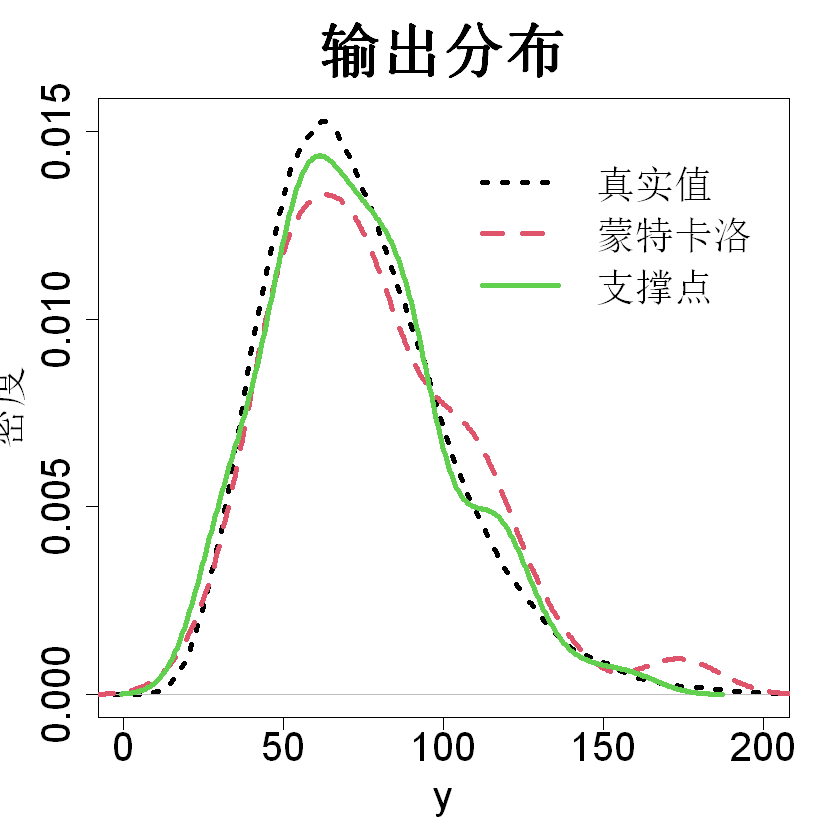

In [8]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.8-plot.RData")){
  library(support)
  f=function(x) 2*pi*x[3]*(x[4]-x[6])/(log(x[2]/x[1])*(1+2*x[7]*x[3]/(log(x[2]/x[1])*x[1]^2*x[8])+x[3]/x[5]))
  p=8; N=100000; n=100
  lower=c(0.05,100,63070,990,63.1,700,1120,9855)
  upper=c(0.15,50000,115600,1110,116,820,1680,12045)
  set.seed(1)
  X1=0.1+0.01618*rnorm(N)
  X2=exp(7.71+1.0056*rnorm(N))
  X=matrix(0,nrow=N,ncol=p)
  X[,1:2]=cbind(X1,X2)
  X[,3:p]=matrix(runif(N*6),nrow=N)
  X[,3:p]=sweep(X[,3:p],2,upper[3:p]-lower[3:p],"*")
  X[,3:p]=sweep(X[,3:p],2,lower[3:p],"+")
  true=apply(X,1,f) # 100000x1
  x=X[sample(1:N,n),]
  mc=apply(x,1,f) # 100x1
  mu=apply(X,2,mean)
  sigma=apply(X,2,sd)
  Z=sweep(X,2,mu,"-")
  Z=sweep(Z,2,sigma,"/")
  D=sp(n,p,dist.samp=Z)$sp
  D=sweep(D,2,sigma,"*")
  D=sweep(D,2,mu,"+")
  y=apply(D,1,f) # 100x1
  save(true,mc,y,file="data/5.8-plot.RData")
}

load("data/5.8-plot.RData")

options(repr.plot.width=7,repr.plot.height=7)
plot(density(true),lty=3,lwd=4,xlim=c(0,200),cex.axis=2,xlab="y",ylab="密度",cex.lab=2,main="输出分布",cex.main=3)
lines(density(mc),col=2,lty=2,lwd=4)
lines(density(y),col=3,lwd=4)
legend(100,.015,legend=c("真实值","蒙特卡洛","支撑点"),col=c(1,2,3),lwd=4,lty=c(3,2,1),bty="n",cex=2)

> **图 5.9**：该混合正态示例中，来自种群蒙特卡洛（左图）与种群拟蒙特卡洛（右图）的 800 个样本（红色叉号）以及最终的候选中心集合（蓝色实心圆）。

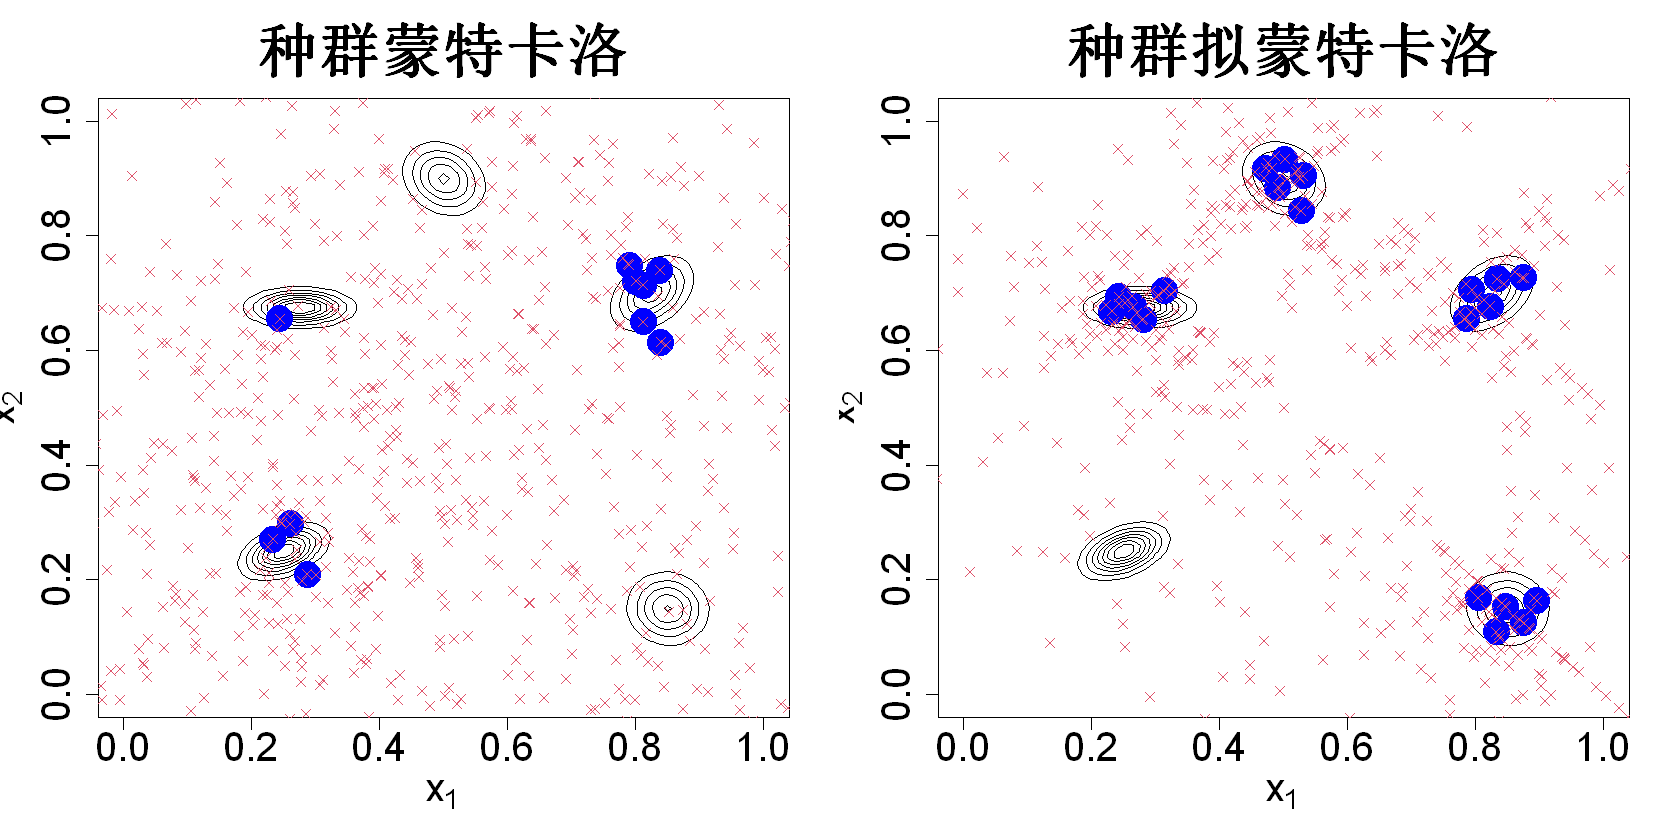

In [9]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/5.9-plot.RData")){
  source("data/lib.r")
  library(mvtnorm)
  library(randtoolbox)
  logmixture=function(x){
    v=matrix(NA,nrow=5,ncol=2)
    v[1,]=c(-10,-10)
    v[2,]=c(0,16)
    v[3,]=c(13,8)
    v[4,]=c(-9,7)
    v[5,]=c(14,-14)
    v=(v+20)/40
    sigma=array(NA,dim=c(5,2,2))
    sigma[1,,]=matrix(c(2,0.6,0.6,1),nrow=2)/40^2
    sigma[2,,]=matrix(c(2,-0.4,-0.4,2),nrow=2)/40^2
    sigma[3,,]=matrix(c(2,0.8,0.8,2),nrow=2)/40^2
    sigma[4,,]=matrix(c(3,0,0,0.5),nrow=2)/40^2
    sigma[5,,]=matrix(c(2,-0.1,-0.1,2),nrow=2)/40^2
    logf=rep(0,5)
    for(i in 1:5) logf[i]=dmvnorm(x,mean=v[i,],sigma=sigma[i,,],log=TRUE)
    logaddexp(logf)-log(5)
  }
  x1=x2=seq(0,1,length.out=101) # 101x1
  x.grid=expand.grid(x1,x2) # 10201x2
  density=matrix(exp(apply(x.grid,1,logmixture)),101,101) # 101x101
  set.seed(1)
  p=2; K=20; J=10; steps=4
  ini=sobol(K,p) # 20x2 初始中心
  sigma=0.2 # 初始协方差
  pmc.mn=pmc(logmixture,K,J,steps,ini,sampling="random",resampling="multinomial",sigma=sigma,sigma.adapt=FALSE,visualization=F,output="weighted samples")
  pqmc.isp=pmc(logmixture,K,J,steps,ini,sampling="qmc",resampling="sp",sigma=sigma,sigma.adapt=TRUE,visualization=F,output="weighted samples")
  pmc.center=pmc.mn$center.all; pqmc.center=pqmc.isp$center.all
  pmc.samp=pmc.mn$samp.all; pqmc.samp=pqmc.isp$samp.all
  save(x1,x2,density,K,steps,pmc.center,pqmc.center,pmc.samp,pqmc.samp,file="data/5.9-plot.RData")
}

load("data/5.9-plot.RData")

options(repr.plot.width=14,repr.plot.height=7)
par(mfrow=c(1,2))
contour.default(x=x1,y=x2,z=density,drawlabels=FALSE,nlevels=10,main="种群蒙特卡洛",cex.main=3,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
points(pmc.center[(K*steps+1):(K*steps+K),],col="blue",pch=16,cex=3)
points(pmc.samp,col=2,pch=4,cex=1)
contour.default(x=x1,y=x2,z=density,drawlabels=FALSE,nlevels=10,main="种群拟蒙特卡洛",cex.main=3,xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2)
points(pqmc.center[(K*steps+1):(K*steps+K),],col="blue",pch=16,cex=3)
points(pqmc.samp,col=2,pch=4,cex=1)